### Downstream analysis for MAGSs-HMM Annotation, module: mags_hmm_annotation
Raw reads count are aggregated for all the samples using the geomosaic command:
```bash
geomosaic gather -s gmsetup.yaml -p mags_hmmsearch --mags_hmmsearch_outfolder hmm_proka_paper

```

In [7]:
# Imports
library(phyloseq)
library(readr)
library(dplyr)
library(tidyr)
library(tidyverse)
library(stringr)
library(ggplot2)
library(vegan)
library(pheatmap)
library(ComplexHeatmap)
library(circlize)

options(readr.show_col_types = FALSE)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ purrr     1.2.1
✔ lubridate 1.9.5     ✔ tibble    3.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
theme_glab <- function(base_size = 11, base_family = "") {
  theme_bw(base_size = base_size, base_family = base_family) %+replace%
    theme(
      legend.background = element_blank(),
      legend.title      = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65),
        hjust = 0
      ),
      legend.text       = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      legend.key.size   = unit(0.8, "lines"),
      plot.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        hjust = 0.5, 
        face = "bold"
      ),
      axis.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      axis.text         = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      panel.grid.major  = element_blank(),
      panel.grid.minor  = element_blank(),
      panel.border      = element_rect(
        fill = NA,
        colour = rgb(100, 100, 100, maxColorValue = 255)
      ),
      complete = TRUE
    )
}

In [ ]:
# 1. List all HMM coverage files from your 8 samples
# Geomosaic organizes these in {wdir}/{sample}/{mags_hmmsearch_output_folder}
files <- list.files(path = "../tables/gm_gathering/mags_hmmsearch", pattern = "mags.tsv", recursive = TRUE, full.names = TRUE)


[1] "../tables/gm_gathering/mags_hmmsearch/CR18_ER180415_F/mags.tsv"
[2] "../tables/gm_gathering/mags_hmmsearch/CR18_ER180415_S/mags.tsv"
[3] "../tables/gm_gathering/mags_hmmsearch/CR18_LE180416_F/mags.tsv"
[4] "../tables/gm_gathering/mags_hmmsearch/CR18_LE180416_S/mags.tsv"
[5] "../tables/gm_gathering/mags_hmmsearch/CR18_LW180405_F/mags.tsv"
[6] "../tables/gm_gathering/mags_hmmsearch/CR18_LW180405_S/mags.tsv"
[7] "../tables/gm_gathering/mags_hmmsearch/CR18_XF180416_F/mags.tsv"
[8] "../tables/gm_gathering/mags_hmmsearch/CR18_XF180416_S/mags.tsv"

In [ ]:
all_data <- map_df(files, function(f) {
  # 1. Extract sample name from the directory path
  s_name <- basename(dirname(f)) 
  
  # 2. Read the matrix
  df <- read_delim(f, delim = "\t")
  
  # 3. Pivot from wide to long
  # We keep 'HMM_model' and turn all 'mag_X' columns into a single 'MAG_ID' column
  df_long <- df %>%
    pivot_longer(
      cols = -HMM_model, 
      names_to = "local_mag", 
      values_to = "presence_val"
    ) %>%
    # 4. Create the Global Unique ID and clean the binary value
    mutate(
      Global_MAG_ID = paste0(s_name, "_", local_mag),
      binary_value = ifelse(presence_val == "0", 0, 1)
    ) %>%
    select(HMM_model, Global_MAG_ID, binary_value)
  
  return(df_long)
})

master_matrix <- all_data %>%
  pivot_wider(
    names_from = Global_MAG_ID, 
    values_from = binary_value, 
    values_fill = 0
  )

In [12]:
master_df <- as.data.frame(master_matrix)
rownames(master_df) <- master_df$HMM_model
master_df$HMM_model <- NULL

In [24]:
ko_metadata <- read_delim("../tables/geomosaic_biogeochemical_kos_plot.tsv", delim = "\t")

In [33]:
plot_data <- master_matrix %>%
  inner_join(ko_metadata, by = c("HMM_model" = "KO")) %>%
  arrange(cycle) # Group them by biological function

In [34]:
plot_data
dim(plot_data)

HMM_model,CR18_ER180415_F_mag_9,CR18_ER180415_F_mag_8,CR18_ER180415_F_mag_1,CR18_ER180415_F_mag_6,CR18_ER180415_F_mag_3,CR18_ER180415_F_mag_7,CR18_ER180415_F_mag_5,CR18_ER180415_F_mag_2,CR18_ER180415_F_mag_11,⋯,Relevance,cycle,Pathway,pathway name,gene,gene_name,key_gene,energyRole,biogeoSubstrate,Metal
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
K08355,1,1,1,0,0,0,0,1,0,⋯,Biogeochemistry,Arsenic,AsOx,Arsenite oxidation,aoxA,arsenite oxidase small subunit [EC:1.20.2.1 1.20.9.1],yes,D,Arsenite,Mo
K08356,1,0,1,0,0,1,0,1,0,⋯,Biogeochemistry,Arsenic,AsOx,Arsenite oxidation,aoxB,arsenite oxidase large subunit [EC:1.20.2.1 1.20.9.1],yes,D,Arsenite,Mo
K05299,1,0,0,0,0,1,1,0,0,⋯,Biogeochemistry,Carbon fixation,WL,Wood-Ljungdahl pathway,fdhA,formate dehydrogenase (NADP+) alpha subunit [EC:1.17.1.10],yes,D,Hydrogen/CO2,"Mo, W"
K15022,1,1,1,0,1,1,0,1,0,⋯,Biogeochemistry,Carbon fixation,WL,Wood-Ljungdahl pathway,fdhB,formate dehydrogenase (NADP+) beta subunit [EC:1.17.1.10],yes,D,Hydrogen/CO2,"Mo, W"
K00193,0,0,0,0,0,0,0,0,0,⋯,Biogeochemistry,Carbon fixation,WL,Wood-Ljungdahl pathway,cdhC,"acetyl-CoA decarbonylase/synthase, CODH/ACS complex subunit beta [EC:2.3.1.169 1.2.7.4]",yes,A,CO2,"NiCu, Ni"
K00194,0,0,0,0,0,0,0,0,0,⋯,Biogeochemistry,Carbon fixation,WL,Wood-Ljungdahl pathway,"cdhD, acsD","acetyl-CoA decarbonylase/synthase, CODH/ACS complex subunit delta [EC:2.1.1.245 1.2.7.4]",yes,A,CO2,"NiCu, Ni"
K00197,0,0,0,0,0,0,0,0,0,⋯,Biogeochemistry,Carbon fixation,WL,Wood-Ljungdahl pathway,"cdhE, acsC","acetyl-CoA decarbonylase/synthase, CODH/ACS complex subunit gamma [EC:2.1.1.245 1.2.7.4]",yes,A,CO2,"NiCu, Ni"
K00198,0,0,0,0,0,0,0,0,0,⋯,Biogeochemistry,Carbon fixation,WL,Wood-Ljungdahl pathway,"cooS, acsA",anaerobic carbon-monoxide dehydrogenase catalytic subunit [EC:1.2.7.4],yes,A,CO2,"NiCu, Ni"
K03520,0,0,0,0,0,1,1,0,0,⋯,Biogeochemistry,Carbon monoxide,Carbon monoxide oxidation,Oxidation of CO to CO2,coxL,aerobic carbon-monoxide dehydrogenase,yes,D,CO,CuMo


[1] 133 198

In [35]:
unique_cats <- unique(plot_data$cycle)

# Generate a palette automatically (using 1 color per category)
library(RColorBrewer)
my_palette <- brewer.pal(n = max(3, length(unique_cats)), name = "Set1")

# Create the named vector: c("Nitrogen" = "#E41A1C", "Carbon" = "#377EB8", ...)
cat_colors <- setNames(my_palette[1:length(unique_cats)], unique_cats)

Warning message:
“`offset` is deprecated, use `location` instead.”


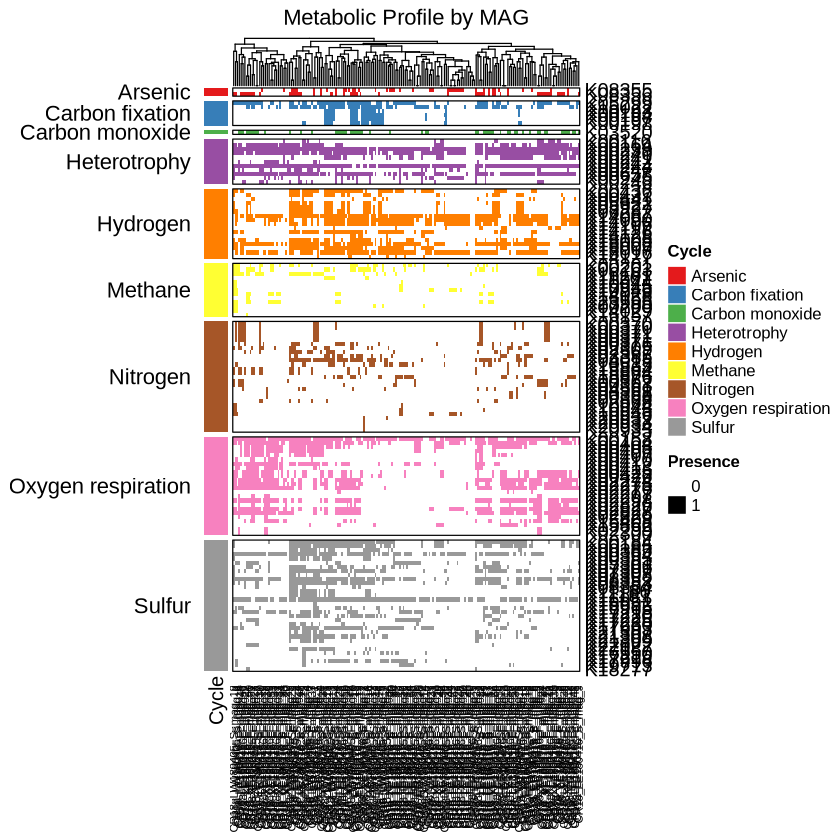

In [47]:
# 1. Ensure cat_colors is ready (as we did before)
unique_cats <- unique(plot_data$cycle)
cat_colors <- setNames(RColorBrewer::brewer.pal(length(unique_cats), "Set1"), unique_cats)

mag_labels = anno_text(colnames(mat), 
                       rot = 90, 
                       just = "right", 
                       offset = unit(1, "npc") - unit(2, "mm"),
                       gp = gpar(fontsize = 7))

# 2. Build the Heatmap with layer_fun
hb <- Heatmap(mat, 
        name = "Presence",
        col = c("0" = "white", "1" = "black"), # Base grid
        
        # VECTORIZED COLORING (Faster for >100 rows/cols)
        layer_fun = function(j, i, x, y, width, height, fill) {
            # Find the index of all '1' values in the matrix
            v = pindex(mat, i, j)
            
            # Only draw where value is 1
            l = v == 1
            
            # Map the category color to the specific row index 'i'
            grid.rect(x[l], y[l], width[l], height[l], 
                      gp = gpar(fill = cat_colors[plot_data$cycle[i[l]]], col = NA))
        },
        
        # Row and Column structure
        row_split = plot_data$cycle,
        cluster_rows = FALSE, 
        cluster_columns = TRUE, 
        show_column_names = FALSE,
        row_title_rot = 0,
        bottom_annotation = HeatmapAnnotation(MAG_IDs = mag_labels),
        column_title = "Metabolic Profile by MAG",
        column_title_side = "top",
        # Annotations
        left_annotation = rowAnnotation(Cycle = plot_data$cycle, col = list(Cycle = cat_colors)),
        border = TRUE)

draw(hb)

Warning message:
“You defined `cell_fun` for a heatmap with more than 100 rows or
columns, which might be very slow to draw. Consider to use the
vectorized version `layer_fun`.”


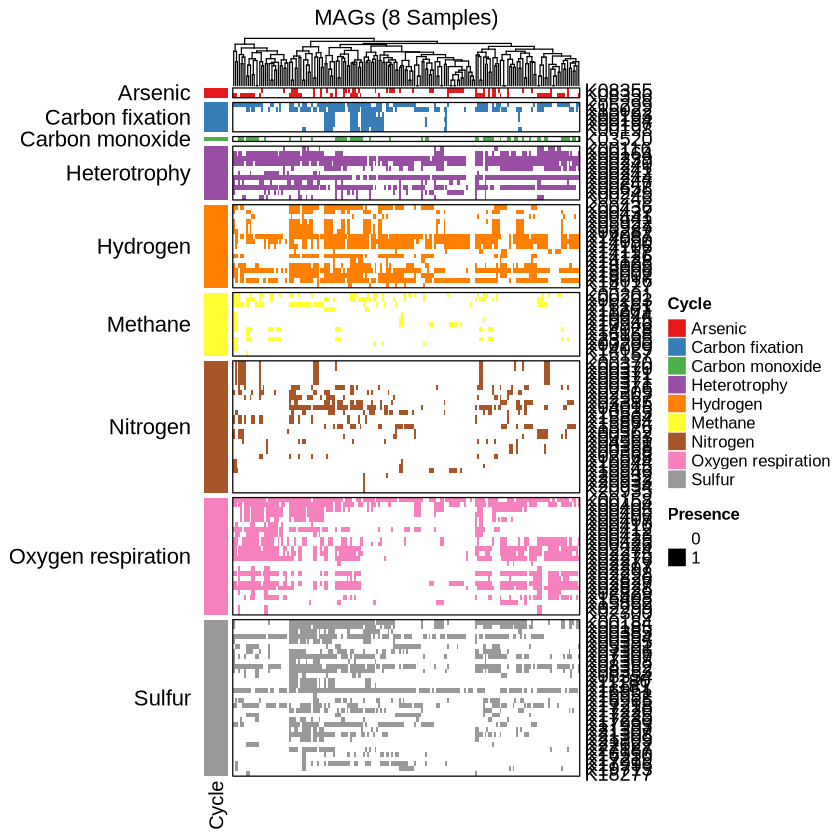

In [41]:
# 1. Create the Row Annotation (The color bar on the left)
row_ha = rowAnnotation(
    Cycle = plot_data$cycle, 
    col = list(Cycle = cat_colors),
    show_legend = TRUE
)

# 2. Build the Heatmap
hb <- Heatmap(mat, 
        name = "Presence",
        col = c("0" = "white", "1" = "black"), # Base colors
        
        # This logic colors the '1's based on the row's Category
        cell_fun = function(j, i, x, y, width, height, fill) {
            if(mat[i, j] == 1) {
                grid.rect(x, y, width, height, 
                          gp = gpar(fill = cat_colors[plot_data$cycle[i]], col = NA))
            }
        },
        
        left_annotation = row_ha, # Adds the color bar
        row_split = plot_data$cycle,
        cluster_rows = FALSE, 
        show_column_names = FALSE,
        row_title_rot = 0,
        column_title = "MAGs (8 Samples)",
        border = TRUE)

draw(hb, heatmap_legend_side = "right", annotation_legend_side = "right")

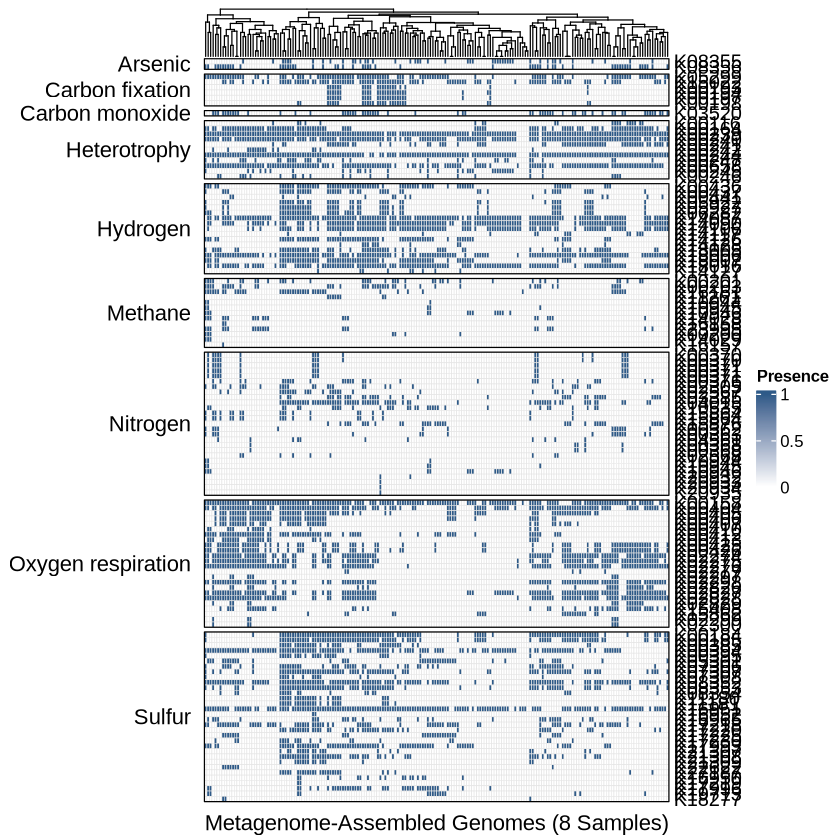

In [36]:
mat <- plot_data %>% 
  select(starts_with("CR18_")) %>% # Selects columns like S1_mag_1, S2_mag_1...
  as.matrix()

rownames(mat) <- plot_data$HMM_model

# 2. Define colors (Binary: 0 = White, 1 = Your Lab Color)
col_fun = colorRamp2(c(0, 1), c("white", "#2E5A88")) 

# 3. Generate the Heatmap
hb <- Heatmap(mat, 
        name = "Presence",
        col = col_fun,
        
        # Row options (Functional Grouping)
        row_split = plot_data$cycle, # This creates the gaps between N, C, S cycles
        row_title_rot = 0,
        cluster_rows = FALSE, # Keep the order from your template
        
        # Column options (MAGs)
        column_split = str_extract(colnames(mat), "^S[0-9]+"), # Split by Sample ID
        column_title_side = "bottom",
        show_column_names = FALSE, # Too many MAGs to show names clearly
        
        # Aesthetics
        border = TRUE,
        rect_gp = gpar(col = "gray90", lwd = 0.5), # Thin grid lines
        column_title = "Metagenome-Assembled Genomes (8 Samples)")

# Draw it!
draw(hb, merge_legend = TRUE)

# second part
geomosaic_biogeochemical_kos.tsv
ko_metadata <- read_delim("../tables/geomosaic_biogeochemical_kos", delim = "\t")

In [37]:
raw_data <- as.data.frame(read_delim("../tables/mags_hmm_annotation/mags.tsv",
                       delim = "\t",
                       ))
rownames(raw_data) <- raw_data$HMM_model
raw_data$HMM_model <- NULL

ERROR: [1m[33mError[39m:[22m
[1m[22m[33m![39m [34m../tables/mags_hmm_annotation/mags.tsv[39m does not exist in current
  working directory: [34m/home/edo/working_dir/geomosaic_cookbook/notebooks[39m.


In [ ]:
View(raw_data[0:4, ])

,mag_9,mag_8,mag_1,mag_6,mag_3,mag_7,mag_5,mag_2,mag_11,mag_4,mag_10
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
K00003,mag_9,mag_8,mag_1,mag_6,0,mag_7,mag_5,mag_2,0,mag_4,mag_10
K00004,mag_9,mag_8,0,mag_6,0,mag_7,mag_5,mag_2,mag_11,0,0
K00005,0,mag_8,0,0,0,0,mag_5,0,0,0,0
K00007,0,0,0,0,0,mag_7,0,0,0,0,0


In [ ]:
binary_matrix <- as.data.frame(lapply(raw_data, function(x) ifelse(x != "0", 1, 0)))
rownames(binary_matrix) <- rownames(raw_data)
# Sort so mag_2 comes before mag_10
sorted_names <- str_sort(colnames(binary_matrix), numeric = TRUE)
binary_matrix <- binary_matrix[, sorted_names]
View(binary_matrix[0:4, ])


,mag_1,mag_2,mag_3,mag_4,mag_5,mag_6,mag_7,mag_8,mag_9,mag_10,mag_11
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
K00003,1,1,0,1,1,1,1,1,1,1,0
K00004,0,1,0,0,1,1,1,1,1,0,1
K00005,0,0,0,0,1,0,0,1,0,0,0
K00007,0,0,0,0,0,0,1,0,0,0,0


In [ ]:
# selecting carbon related KOs
kos_table <- as.data.frame(read_delim("../tables/ko_carbon_metab.csv",
  delim = ","
))

kos <- kos_table$ko
present_kos <- kos[kos %in% rownames(binary_matrix)]
final_matrix <- binary_matrix[present_kos, ]

In [ ]:
# Carbon related KOs from 
# url_bige = 'https://raw.githubusercontent.com/ArnaudBelcour/bigecyhmm/refs/heads/main/bigecyhmm/hmm_databases/hmm_table_template.tsv'

kos <- c('K01938', 'K18861', 'K15231', 'K14466', 'K00197', 'K14469', 'K15230', 'K00198', 'K01601', 'K14467', 'K14468', 'K00194')
present_kos <- kos[kos %in% rownames(binary_matrix)]
final_matrix <- as.matrix(binary_matrix[present_kos, ])

In [ ]:
class(present_kos)
dim(kos)
dim(final_matrix)

[1] "character"

NULL

[1]  5 11

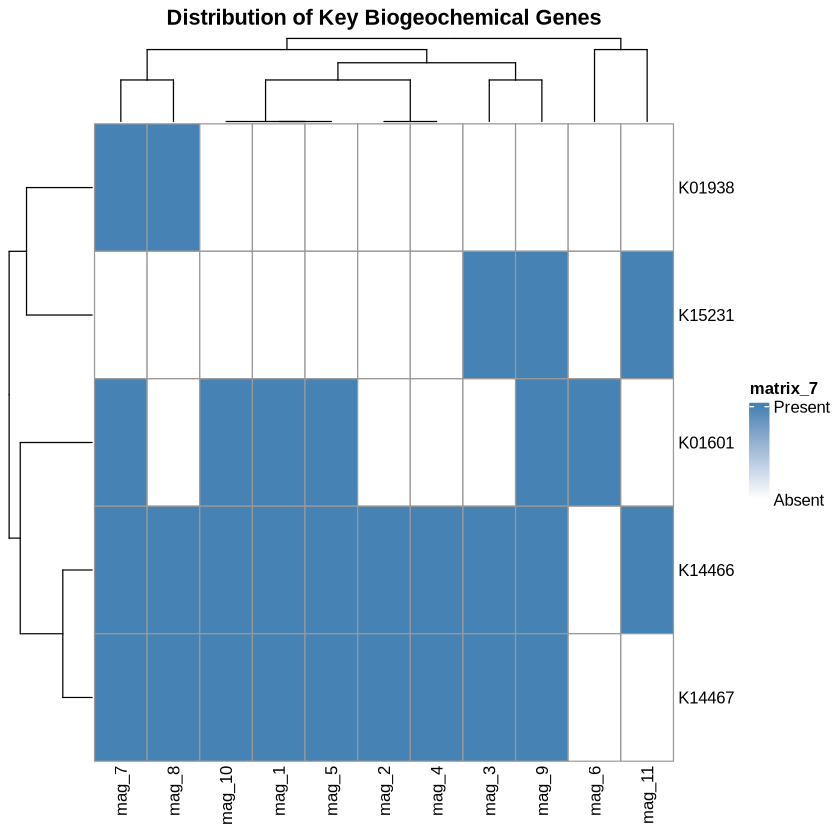

In [ ]:
pheatmap(final_matrix, 
         color = c("white", "steelblue"), 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         legend_breaks = c(0, 1),
         legend_labels = c("Absent", "Present"),
         main = "Distribution of Key Biogeochemical Genes")

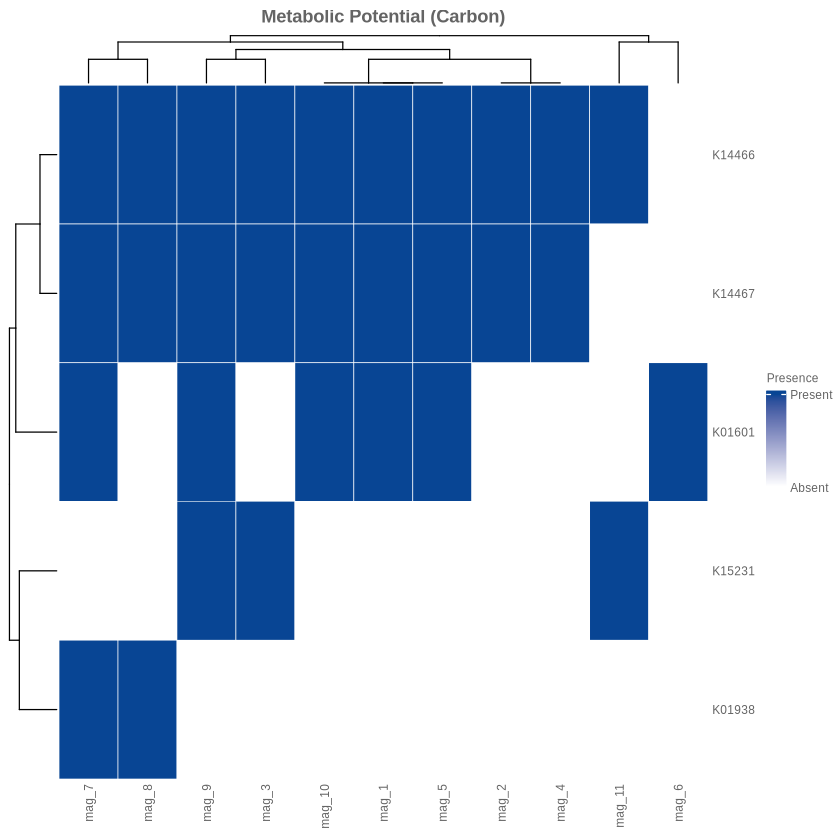

In [ ]:
library(ComplexHeatmap)
library(circlize)
# 1. Define the core color from your theme_glab
glab_gray <- rgb(100, 100, 100, maxColorValue = 255)
# 2. Setup the Heatmap with theme_glab's visual identity
# Using your theme's font sizing (rel(0.65) of 11 is ~7.15)
ht <- Heatmap(final_matrix,
        name = "Presence",
        # Color palette: White to a bold Blue, consistent with your theme's clean BW base
        col = colorRamp2(c(0, 1), c("#FFFFFF", "#084594")),
        # Grid settings matching your panel.border and element_blank() grid
        rect_gp = gpar(col = "white", lwd = 0.5), 
        column_title = "Metabolic Potential (Carbon)",
        column_title_gp = gpar(col = glab_gray, fontsize = 11, fontface = "bold"),
        # Axis/Labels matching your axis.text and axis.title specs
        row_names_gp = gpar(col = glab_gray, fontsize = 7.15),
        column_names_gp = gpar(col = glab_gray, fontsize = 7.15),
        # Clustering options
        cluster_rows = TRUE,
        cluster_columns = TRUE,
        # Legend styling matching your legend.text and legend.title
        heatmap_legend_param = list(
            title_gp = gpar(col = glab_gray, fontsize = 7.15),
            labels_gp = gpar(col = glab_gray, fontsize = 7.15),
            grid_height = unit(0.8, "lines"),
            at = c(0, 1),
            labels = c("Absent", "Present")
        )
)
# 3. Draw with a clean border matching your panel.border
draw(ht, padding = unit(c(2, 2, 2, 2), "mm"))

In [ ]:
ht <- Heatmap(carbon_matrix, 
        name = "Presence", 
        col = col_fun,
        # Clustering & Structure
        cluster_rows = TRUE, 
        cluster_columns = TRUE,
        column_title = "Reconstructed MAGs (Carbon Metabolism)",
        row_title = "HMM Models (KOs)",
        # Visual Styling
        rect_gp = gpar(col = "white", lwd = 1), # White borders between tiles
        show_row_dend = TRUE, 
        show_column_dend = TRUE,
        # Legend Customization
        heatmap_legend_param = list(
            at = c(0, 1), 
            labels = c("Absent", "Present"),
            title = "Status"
        ),
        
        # Font settings for scientific readability
        row_names_gp = gpar(fontsize = 9, fontfamily = "sans"),
        column_names_gp = gpar(fontsize = 10, fontfamily = "sans")
)

Warning message:
“The input is a data frame-like object, convert it to a matrix.”


ERROR: Error: object 'col_fun' not found


A) Phylogenetic tree of the obtained MAGs taxonomically identified using the GTDB-tk module and plotted using iTOL. B) Heatmap of the distribution of key biogeochemical genes obtained using the MAGs-HMM Annotation (MAG-HMMA) module and plotted in R.